In [ ]:
"""
problemas.py

"""

import numpy as np


def _suma_violaciones(g):
    """
    Convierte el vector de restricciones g(x) <= 0 en un único escalar phi(x).

    Para cada restricción se toma solo la parte que VIOLA la regla, es decir
    max(0, g_i). Si g_i <= 0 la restricción se cumple y no aporta penalización.
    Se elevan al cuadrado para castigar con más fuerza las violaciones grandes,
    siguiendo la formulación clásica de Runarsson & Yao.

    Parámetros
    ----------
    g : np.ndarray  -> vector con el valor de cada restricción g_i(x).

    Retorna
    -------
    float -> phi(x), la magnitud total de violación (0 si es factible).
    """
    violaciones = np.maximum(0.0, g)      # solo cuenta lo que excede el límite
    return float(np.sum(violaciones ** 2))


# =====================================================================
# PROBLEMA 1: RESORTE DE COMPRESIÓN (Tension/Compression Spring)
# =====================================================================
class ResorteCompresion:
    """
    Minimiza el peso de un resorte de compresión.

    Variables de diseño:
        x[0] = d : diámetro del alambre.
        x[1] = D : diámetro medio de la espira.
        x[2] = N : número de espiras activas.

    Función objetivo:
        f(x) = (N + 2) * D * d^2
    """

    def __init__(self):
        # Etiqueta usada en gráficas y en la tabla de resultados.
        self.nombre = "Resorte"
        # Límites inferiores [d, D, N].
        self.lb = np.array([0.05, 0.25, 2.0])
        # Límites superiores [d, D, N].
        self.ub = np.array([2.00, 1.30, 15.0])
        # Número de variables del problema.
        self.dim = 3

    def objetivo(self, x):
        """Peso (volumen) del resorte: (N + 2) * D * d^2."""
        d, D, N = x[0], x[1], x[2]
        return (N + 2.0) * D * d ** 2

    def _restricciones(self, x):
        """
        Calcula el vector g(x) de las 4 restricciones de desigualdad g_i <= 0:
            g1: límite de esfuerzo cortante.
            g2: límite de deflexión.
            g3: límite de frecuencia de oscilación libre.
            g4: límite de diámetro exterior.
        """
        d, D, N = x[0], x[1], x[2]
        g = np.zeros(4)
        g[0] = 1.0 - (D ** 3 * N) / (71785.0 * d ** 4)
        g[1] = (4.0 * D ** 2 - d * D) / (12566.0 * (D * d ** 3 - d ** 4)) \
               + 1.0 / (5108.0 * d ** 2) - 1.0
        g[2] = 1.0 - 140.45 * d / (D ** 2 * N)
        g[3] = (d + D) / 1.5 - 1.0
        return g

    def violacion(self, x):
        """phi(x): magnitud total de violación de las 4 restricciones."""
        return _suma_violaciones(self._restricciones(x))


# =====================================================================
# PROBLEMA 2: VIGA SOLDADA (Welded Beam)
# =====================================================================
class VigaSoldada:
    """
    Minimiza el costo de fabricación de una viga soldada sujeta a 7
    restricciones físicas (esfuerzo cortante, flexión, pandeo, deflexión y
    geometría).

    Variables de diseño:
        x[0] = h : altura del cordón de soldadura.
        x[1] = l : longitud de la soldadura.
        x[2] = t : altura de la viga.
        x[3] = b : espesor de la viga.

    Función objetivo:
        f(x) = 1.10471 * h^2 * l + 0.04811 * t * b * (14 + l)
    """

    # Constantes físicas del problema (unidades imperiales).
    P = 6000.0          # carga aplicada (lb)
    L = 14.0            # longitud (in)
    E = 30e6            # módulo de elasticidad (psi)
    G = 12e6            # módulo de corte (psi)
    TAU_MAX = 13600.0   # esfuerzo cortante máximo admisible (psi)
    SIGMA_MAX = 30000.0 # esfuerzo normal máximo admisible (psi)
    DELTA_MAX = 0.25    # deflexión máxima admisible (in)

    def __init__(self):
        self.nombre = "Viga"
        self.lb = np.array([0.1, 0.1, 0.1, 0.1])
        self.ub = np.array([2.0, 10.0, 10.0, 2.0])
        self.dim = 4

    def objetivo(self, x):
        """Costo de fabricación de la viga."""
        h, l, t, b = x[0], x[1], x[2], x[3]
        return 1.10471 * h ** 2 * l + 0.04811 * t * b * (14.0 + l)

    def _restricciones(self, x):
        """
        Calcula el vector g(x) de las 7 restricciones g_i <= 0 a partir de los
        modelos de esfuerzo (tau, sigma), deflexión (delta) y carga crítica de
        pandeo (Pc).
        """
        h, l, t, b = x[0], x[1], x[2], x[3]
        P, L, E, Gmod = self.P, self.L, self.E, self.G

        # --- Esfuerzo cortante combinado tau(x) ---
        M = P * (L + l / 2.0)                       # momento flector
        R = np.sqrt(l ** 2 / 4.0 + ((h + t) / 2.0) ** 2)
        J = 2.0 * (np.sqrt(2.0) * h * l *
                   (l ** 2 / 12.0 + ((h + t) / 2.0) ** 2))
        tau_p = P / (np.sqrt(2.0) * h * l)          # cortante primario
        tau_pp = M * R / J                          # cortante secundario
        tau = np.sqrt(tau_p ** 2
                      + 2.0 * tau_p * tau_pp * l / (2.0 * R)
                      + tau_pp ** 2)

        # --- Esfuerzo normal por flexión sigma(x) ---
        sigma = 6.0 * P * L / (b * t ** 2)

        # --- Deflexión del extremo delta(x) ---
        delta = 4.0 * P * L ** 3 / (E * t ** 3 * b)

        # --- Carga crítica de pandeo Pc(x) ---
        Pc = (4.013 * E * np.sqrt(t ** 2 * b ** 6 / 36.0) / L ** 2) \
             * (1.0 - t / (2.0 * L) * np.sqrt(E / (4.0 * Gmod)))

        g = np.zeros(7)
        g[0] = tau - self.TAU_MAX                   # esfuerzo cortante
        g[1] = sigma - self.SIGMA_MAX               # esfuerzo normal
        g[2] = h - b                                # geometría (h <= b)
        g[3] = 0.10471 * h ** 2 + 0.04811 * t * b * (14.0 + l) - 5.0  # costo
        g[4] = 0.125 - h                            # altura mínima soldadura
        g[5] = delta - self.DELTA_MAX               # deflexión
        g[6] = P - Pc                               # pandeo
        return g

    def violacion(self, x):
        """phi(x): magnitud total de violación de las 7 restricciones."""
        return _suma_violaciones(self._restricciones(x))


In [ ]:
"""
algoritmo_luciernaga.py (Modificado con Auto-adaptación)

Parámetro clave Pf:
    Pf alto  (0.8)  -> permisivo: prioriza f, tiende a soluciones infactibles.
    Pf bajo  (0.2)  -> conservador: prioriza phi, puede estancarse.
    Pf medio (0.45) -> balance entre explorar y respetar la física.
"""

import numpy as np

# =====================================================================
# OPERADOR DE JERARQUÍAS ESTOCÁSTICAS (STOCHASTIC RANKING)
# =====================================================================
def stochastic_ranking(f, phi, Pf, sweeps=None):
    N = len(f)
    idx = np.arange(N)
    if sweeps is None:
        sweeps = N

    for _ in range(sweeps):
        intercambio = False
        for j in range(N - 1):
            a, b = idx[j], idx[j + 1]
            u = np.random.rand()
            comparar_por_objetivo = (phi[a] == 0 and phi[b] == 0) or (u < Pf)
            if comparar_por_objetivo:
                if f[a] > f[b]:
                    idx[j], idx[j + 1] = b, a
                    intercambio = True
            else:
                if phi[a] > phi[b]:
                    idx[j], idx[j + 1] = b, a
                    intercambio = True
        if not intercambio:
            break
    return idx

# =====================================================================
# REDUCCIÓN DEL PARÁMETRO ALPHA (VERSIÓN CLÁSICA)
# =====================================================================
def _reducir_alpha(alpha, ngen):
    delta = 1.0 - (1e-4 / 0.9) ** (1.0 / ngen)
    return (1.0 - delta) * alpha

# =====================================================================
# EVALUACIÓN DE LA POBLACIÓN
# =====================================================================
def _evaluar(problema, X):
    n = X.shape[0]
    f = np.zeros(n)
    phi = np.zeros(n)
    for i in range(n):
        try:
            fi = problema.objetivo(X[i])
            pi = problema.violacion(X[i])
            if not (np.isfinite(fi) and np.isfinite(pi)):
                fi, pi = 1e15, 1e15
        except (ZeroDivisionError, FloatingPointError, ValueError):
            fi, pi = 1e15, 1e15
        f[i], phi[i] = fi, pi
    return f, phi

# =====================================================================
# ALGORITMO DE LUCIÉRNAGA + JERARQUÍAS ESTOCÁSTICAS + AUTO-ADAPTACIÓN
# =====================================================================
def firefly_sr(problema, n=40, generaciones=200, Pf=0.45,
               alpha=0.5, betamin=0.2, gamma=1.0, semilla=None,
               auto_adapt=False): # <-- NUEVO PARÁMETRO

    if semilla is not None:
        np.random.seed(semilla)

    lb, ub, dim = problema.lb, problema.ub, problema.dim
    escala = np.abs(ub - lb)
    beta0 = 1.0

    X = lb + (ub - lb) * np.random.rand(n, dim)

    mejor_x, mejor_f, mejor_phi = None, np.inf, np.inf
    historia = []
    hist_fact = []

    # Memoria histórica para la auto-adaptación
    f_prev = np.full(n, np.inf)
    phi_prev = np.full(n, np.inf)

    for g in range(generaciones):
        # 1) Evaluar.
        f, phi = _evaluar(problema, X)

        # --- LÓGICA DE AUTO-ADAPTACIÓN (Algorithm 3) ---
        if auto_adapt and g > 0:
            mejoras = 0
            for i in range(n):
                # Determinar si la luciérnaga "i" mejoró respecto a su posición anterior
                mejoro = False
                if phi[i] == 0 and phi_prev[i] > 0:
                    mejoro = True # Se volvió factible
                elif phi[i] == 0 and phi_prev[i] == 0 and f[i] < f_prev[i]:
                    mejoro = True # Ambas factibles, pero bajó costo
                elif phi[i] > 0 and phi_prev[i] > 0 and phi[i] < phi_prev[i]:
                    mejoro = True # Ambas infactibles, pero violó menos las reglas

                if mejoro:
                    mejoras += 1

            # Tasa de éxito (SR)
            SR = mejoras / n

            # Ajuste de parámetros según la tasa de éxito
            if SR > 0.3:
                # Alto éxito: aumentar salto fino y bajar absorción (Explotación)
                alpha = min(alpha * 1.02, 1.0)
                gamma = max(gamma * 0.95, 0.1)
            elif SR < 0.1:
                # Bajo éxito: saltos bruscos y alta absorción (Exploración extrema)
                alpha = max(alpha * 0.90, 1e-4)
                gamma = min(gamma * 1.05, 10.0)
            else:
                # Éxito medio: decaimiento suave
                alpha = alpha * 0.99
        elif not auto_adapt:
            # 4 Clásico) Reducir la aleatoriedad de forma ciega
            alpha = _reducir_alpha(alpha, generaciones)

        # Actualizar memoria histórica para la siguiente iteración
        f_prev, phi_prev = f.copy(), phi.copy()
        # -----------------------------------------------

        # 2) Ordenar por Jerarquías Estocásticas -> brillo (rango) de cada una.
        orden = stochastic_ranking(f, phi, Pf)
        rango = np.empty(n, dtype=int)
        rango[orden] = np.arange(n)

        # 3) Actualizar el mejor global
        for i in range(n):
            es_mejor = (
                (phi[i] == 0 and mejor_phi > 0) or
                (phi[i] == 0 and mejor_phi == 0 and f[i] < mejor_f) or
                (mejor_phi > 0 and phi[i] < mejor_phi)
            )
            if es_mejor:
                mejor_x, mejor_f, mejor_phi = X[i].copy(), f[i], phi[i]

        historia.append(mejor_f)
        hist_fact.append(mejor_phi == 0)

        # 5) Movimiento
        Xo = X.copy()
        for i in range(n):
            for j in range(n):
                if rango[j] < rango[i]:
                    r = np.sqrt(np.sum((X[i] - Xo[j]) ** 2))
                    beta = (beta0 - betamin) * np.exp(-gamma * r ** 2) + betamin
                    paso = alpha * (np.random.rand(dim) - 0.5) * escala

                    X[i] = X[i] * (1 - beta) + Xo[j] * beta + paso
                    X[i] = np.clip(X[i], lb, ub)

    return {
        "x": mejor_x,
        "f": mejor_f,
        "phi": mejor_phi,
        "factible": mejor_phi == 0,
        "historia": np.array(historia),
        "hist_fact": np.array(hist_fact),
        "alpha_final": alpha,  # Retornamos estos valores por si quieres analizarlos
        "gamma_final": gamma
    }


>>> Convergencia del problema: Resorte
  Pf=0.2 (conservador) -> f=0.013305  [FACTIBLE]
  Pf=0.45 (balanceado ) -> f=0.013409  [FACTIBLE]
  Pf=0.8 (agresivo   ) -> f=0.013377  [FACTIBLE]


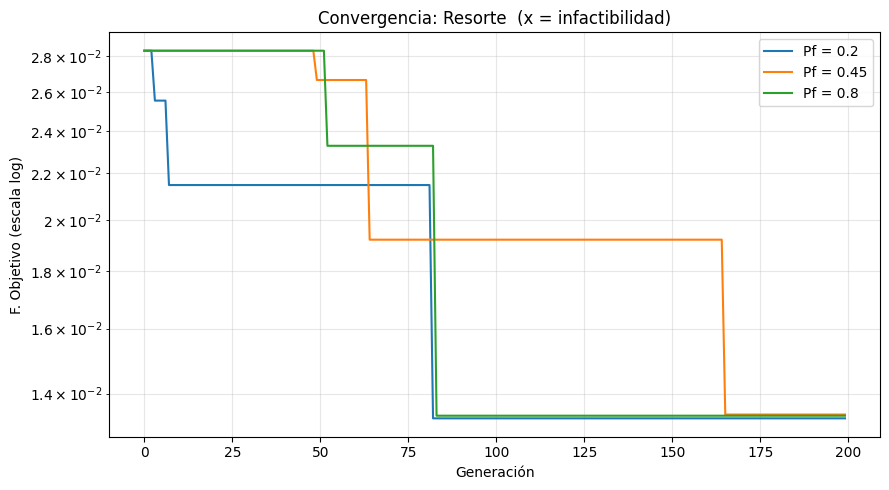

  Gráfica guardada y mostrada: convergencia_resorte.png

>>> Convergencia del problema: Viga
  Pf=0.2 (conservador) -> f=2.939517  [FACTIBLE]
  Pf=0.45 (balanceado ) -> f=2.458416  [FACTIBLE]
  Pf=0.8 (agresivo   ) -> f=2.904370  [FACTIBLE]


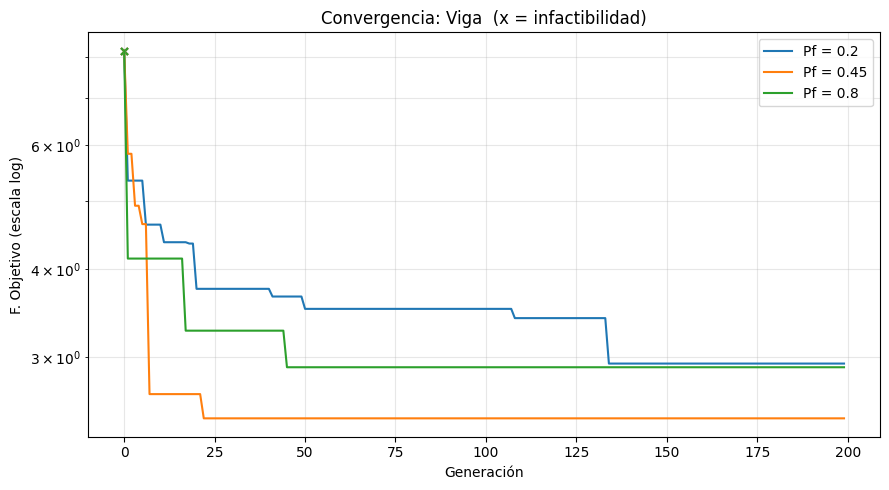

  Gráfica guardada y mostrada: convergencia_viga.png

TABLA DE RESULTADOS FINAL (30 EJECUCIONES POR CASO)
Problema      Pf   Óptimo(prom)   Desv.Est  %Factible
----------------------------------------------------------------
Resorte     0.20       0.013246   0.000140     100.0%
Resorte     0.45       0.014361   0.003260     100.0%
Resorte     0.80       0.015889   0.003482     100.0%
Viga        0.20       2.479309   0.247862     100.0%
Viga        0.45       2.528818   0.218076     100.0%
Viga        0.80       2.649840   0.296108     100.0%


In [ ]:
"""
Experimentos: Luciérnaga para los problemas de restricciones con Auto-adaptación
"""
import numpy as np
import matplotlib.pyplot as plt

# En Google Colab, asegúrate de haber ejecutado antes las celdas con el código
# de los problemas y del algoritmo. Si las clases ya están en la memoria del
# cuaderno, esta importación no fallará.
try:
    from problemas import ResorteCompresion, VigaSoldada
    from algoritmo_luciernaga import firefly_sr
except ImportError:
    pass

# Tres niveles de Pf y un color para cada uno, igual que en el reporte.
NIVELES_PF = [
    (0.20, "tab:blue",   "conservador"),
    (0.45, "tab:orange", "balanceado"),
    (0.80, "tab:green",  "agresivo"),
]

def graficar_convergencia(problema, resultados, archivo):
    """
    Dibuja la curva de convergencia para un problema con los tres valores de Pf.
    """
    plt.figure(figsize=(9, 5))
    for Pf, color, _ in NIVELES_PF:
        r = resultados[Pf]
        hist = r["historia"]
        fact = r["hist_fact"]
        gens = np.arange(len(hist))

        # Línea continua del mejor costo por generación.
        plt.plot(gens, hist, color=color, label=f"Pf = {Pf}")
        # Marca 'x' en las generaciones infactibles.
        infactibles = ~fact
        if np.any(infactibles):
            plt.scatter(gens[infactibles], hist[infactibles],
                        color=color, marker="x", s=25)

    plt.yscale("log")
    plt.xlabel("Generación")
    plt.ylabel("F. Objetivo (escala log)")
    plt.title(f"Convergencia: {problema.nombre}  (x = infactibilidad)")
    plt.legend()
    plt.grid(True, which="both", alpha=0.3)
    plt.tight_layout()

    # Guardar y mostrar la gráfica directamente en pantalla
    plt.savefig(archivo, dpi=120)
    plt.show()
    plt.close()
    print(f"  Gráfica guardada y mostrada: {archivo}")


def experimento_sensibilidad(problema, generaciones):
    """
    Ejecuta una corrida por cada valor de Pf para trazar la convergencia.
    """
    resultados = {}
    for Pf, _, etiqueta in NIVELES_PF:
        r = firefly_sr(
            problema, n=40,
            generaciones=generaciones, Pf=Pf, semilla=7,
            auto_adapt=True  # <-- ¡AQUÍ ACTIVAMOS LA AUTO-ADAPTACIÓN!
        )
        resultados[Pf] = r
        estado = "FACTIBLE" if r["factible"] else "INFACTIBLE"
        print(f"  Pf={Pf} ({etiqueta:11s}) -> f={r['f']:.6f}  [{estado}]")
    return resultados


def tabla_resultados(problemas, generaciones, corridas):
    """
    Repite el experimento 'corridas' veces por cada (problema, Pf) y resume:
        - Óptimo promedio (solo sobre corridas factibles).
        - Desviación estándar de ese óptimo.
        - Porcentaje de corridas que terminaron en solución factible.
    """
    print("\n" + "=" * 64, flush=True)
    print(f"TABLA DE RESULTADOS FINAL ({corridas} EJECUCIONES POR CASO)", flush=True)
    print("=" * 64, flush=True)
    print(f"{'Problema':10s} {'Pf':>5s} {'Óptimo(prom)':>14s} "
          f"{'Desv.Est':>10s} {'%Factible':>10s}", flush=True)
    print("-" * 64, flush=True)

    for problema in problemas:
        for Pf, _, _ in NIVELES_PF:
            optimos_factibles = []
            n_factibles = 0
            for c in range(corridas):
                print(f"  calculando {problema.nombre:8s} Pf={Pf:<4} "
                      f"corrida {c + 1:>2}/{corridas}...",
                      end="\r", flush=True)

                r = firefly_sr(
                    problema, n=40,
                    generaciones=generaciones, Pf=Pf, semilla=c,
                    auto_adapt=True  # <-- ¡AQUÍ TAMBIÉN LO ACTIVAMOS!
                )
                if r["factible"]:
                    n_factibles += 1
                    optimos_factibles.append(r["f"])

            if optimos_factibles:
                prom = np.mean(optimos_factibles)
                desv = np.std(optimos_factibles)
            else:
                prom, desv = float("nan"), float("nan")
            pct = 100.0 * n_factibles / corridas

            print(" " * 60, end="\r")
            print(f"{problema.nombre:10s} {Pf:>5.2f} {prom:>14.6f} "
                  f"{desv:>10.6f} {pct:>9.1f}%", flush=True)
    print("=" * 64, flush=True)


def main():
    """Punto de entrada: lanza todos los experimentos con valores fijos."""

    # ---------------------------------------------------------
    # VARIABLES FIJAS (Sin argparse)
    # ---------------------------------------------------------
    generaciones = 200
    corridas = 30  # Requisito 'f' de la rúbrica

    # Se asume que las clases ResorteCompresion y VigaSoldada están importadas
    problemas = [ResorteCompresion(), VigaSoldada()]

    # --- 1 y 2: análisis de sensibilidad + gráficas de convergencia ---
    for problema in problemas:
        print(f"\n>>> Convergencia del problema: {problema.nombre}")
        res = experimento_sensibilidad(problema, generaciones)
        graficar_convergencia(
            problema, res, f"convergencia_{problema.nombre.lower()}.png")

    # --- 3: tabla resumen sobre múltiples corridas ---
    tabla_resultados(problemas, generaciones, corridas)


# Ejecución directa
if __name__ == "__main__":
    main()

=== EXPERIMENTO DE JERARQUÍAS ESTOCÁSTICAS ===

>>> Analizando Problema: Resorte <<<


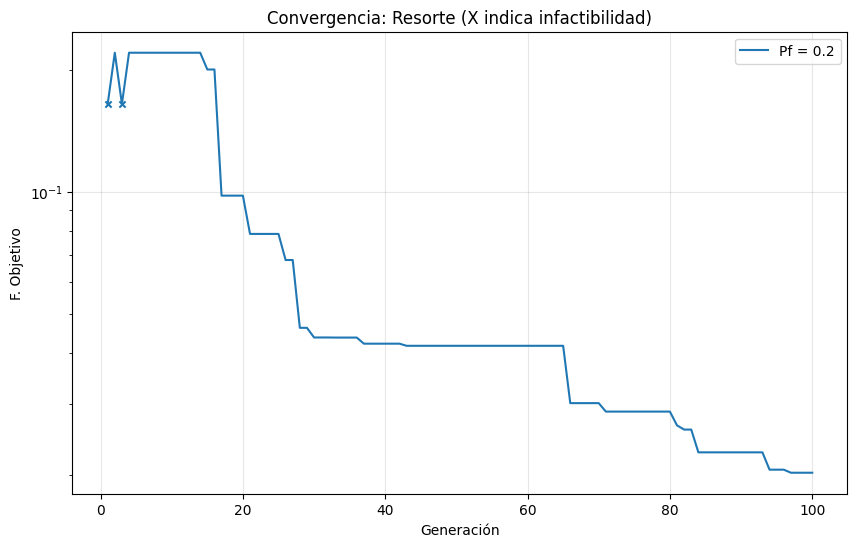

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>


>>> Analizando Problema: Viga <<<


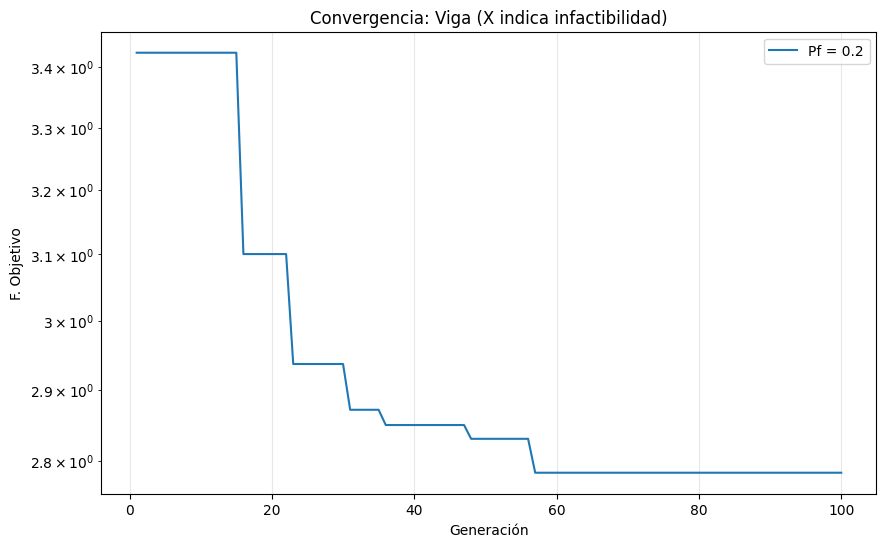

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>


TABLA DE RESULTADOS FINAL (30 EJECUCIONES POR CASO)
Problema   Pf  Óptimo (prom)  Desv. Stand  # Factibles (prom)
 Resorte 0.20       0.020188     0.006435               100.0
 Resorte 0.45       0.019148     0.008431               100.0
 Resorte 0.80       0.003614     0.000708                 0.0
    Viga 0.20       2.754644     0.416170               100.0
    Viga 0.45       2.614765     0.382941               100.0
    Viga 0.80       0.020859     0.006809                 0.0


In [ ]:
import random
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- DEFINICIÓN DE PROBLEMAS (Fórmulas extraídas del PDF de la Práctica 4) ---

def eval_resorte(X):
    t1, t2, t3 = X  # d, D, N
    f = (t3 + 2) * t2 * (t1**2)

    # Restricciones g(x) <= 0 corregidas según PDF
    g = [
        1 - (t2**2 * t3) / (71785 * t1**4),  # g1: t2 al cuadrado
        (4*t2**2 - t1*t2) / (12566 * (t2*t1**3 - t1**4 + 1e-12)) + 1/(5108*t1**2) - 1, # g2
        1 - 140.45 / (t2**3 * t3),           # g3: t2 al cubo
        (t1 + t2) / 1.5 - 1                 # g4
    ]
    phi = sum(max(0, val)**2 for val in g)
    return f, phi

def eval_viga(X):
    x1, x2, x3, x4 = X  # h, l, t, b
    P, L, E, G = 6000, 14, 30e6, 12e6
    tau_max, sigma_max, delta_max = 13600, 30000, 0.25

    f = 1.10471 * x1**2 * x2 + 0.04811 * x3 * x4 * (14.0 + x2)

    # Cálculos intermedios según PDF
    tau_p = P / (math.sqrt(2) * x1 * x2 + 1e-12)
    M = P * (L + x2 / 2)
    R = math.sqrt(x2**2 / 4 + (x1 + x3)**2 / 4)
    J = 2 * (math.sqrt(2) * x1 * x2 * (x2**2 / 12 + (x1 + x3)**2 / 4)) + 1e-12
    tau_pp = (M * R) / J
    tau = math.sqrt(tau_p**2 + 2 * tau_p * tau_pp * (x2 / (2 * R)) + tau_pp**2)

    sigma = (6 * P * L) / (x4 * x3**2 + 1e-12)
    delta = (4 * P * L**3) / (E * x3**3 * x4 + 1e-12)
    Pc = (4.013 * E * math.sqrt(x3**2 * x4**6 / 36) / (L**2)) * (1 - (x3 / (2 * L)) * math.sqrt(E / (4 * G)))

    g = [
        tau - tau_max,
        sigma - sigma_max,
        x1 - x4,
        0.10471 * x1**2 + 0.04811 * x3 * x4 * (14.0 + x2) - 5.0,
        0.125 - x1,
        delta - delta_max,
        P - Pc
    ]
    phi = sum(max(0, val)**2 for val in g)
    return f, phi

# --- LÓGICA DE STOCHASTIC RANKING ---

def stochasticRanking(population, Pf):
    """Ordena la población basándose en Pf para equilibrar factibilidad y objetivo."""
    n = len(population)
    # Burbuja estocástica para el ranking
    for i in range(n):
        swapped = False
        for j in range(n - 1):
            f_j, phi_j = population[j][1], population[j][2]
            f_next, phi_next = population[j+1][1], population[j+1][2]

            # Condición de intercambio
            if (phi_j == 0 and phi_next == 0) or (random.random() < Pf):
                if f_j > f_next:
                    population[j], population[j+1] = population[j+1], population[j]
                    swapped = True
            elif phi_j > phi_next:
                population[j], population[j+1] = population[j+1], population[j]
                swapped = True
        if not swapped: break
    return population

def ejecutar_ag(func_eval, lims, Pf, tam=100, gens=100):
    dim = len(lims[0])
    pob = [[ [random.uniform(lims[0][j], lims[1][j]) for j in range(dim)], 0, 0] for _ in range(tam)]
    for ind in pob: ind[1], ind[2] = func_eval(ind[0])

    hist_f = []
    hist_fact = [] # Para registrar si el mejor de la generación es factible

    for _ in range(gens):
        hijos = []
        indices = list(range(tam))
        random.shuffle(indices)
        for i in range(0, tam, 2):
            p1, p2 = pob[indices[i]][0], pob[indices[i+1]][0]
            alpha = random.random()
            # Cruce Aritmético
            h_xs = [
                [alpha*p1[j] + (1-alpha)*p2[j] for j in range(dim)],
                [(1-alpha)*p1[j] + alpha*p2[j] for j in range(dim)]
            ]
            for hx in h_xs:
                if random.random() < 0.1: # Mutación uniforme simple
                    idx_m = random.randint(0, dim-1)
                    hx[idx_m] = random.uniform(lims[0][idx_m], lims[1][idx_m])
                fh, phih = func_eval(hx)
                hijos.append([hx, fh, phih])

        pob = stochasticRanking(pob + hijos, Pf)[:tam]
        hist_f.append(pob[0][1])
        hist_fact.append(pob[0][2] == 0)

    num_factibles_final = sum(1 for p in pob if p[2] == 0)
    return pob[0], num_factibles_final, hist_f, hist_fact

# --- EJECUCIÓN DEL EXPERIMENTO (MODIFICADO PARA TIEMPO REAL) ---

print("=== EXPERIMENTO DE JERARQUÍAS ESTOCÁSTICAS ===")
Pfs = [0.2, 0.45, 0.8]
problemas = [
    ("Resorte", eval_resorte, [[0.05, 0.25, 2.0], [2.0, 1.30, 15.0]]),
    ("Viga", eval_viga, [[0.1, 0.1, 0.1, 0.1], [2.0, 10.0, 10.0, 2.0]])
]

data_tabla = []

# Variable para controlar el número de ejecuciones independientes
num_ejecuciones = 30

# 1. ACTIVAR MODO INTERACTIVO (Evita que el programa se congele al graficar)
plt.ion()

for p_name, func, lims in problemas:
    # Crear la figura ANTES de evaluar los Pf para que se dibuje en la misma ventana
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.set_title(f"Convergencia: {p_name} (X indica infactibilidad)")
    ax.set_xlabel("Generación")
    ax.set_ylabel("F. Objetivo")
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)

    print(f"\n>>> Analizando Problema: {p_name} <<<")

    for pf in Pfs:
        corridas_f = []
        corridas_fact = []
        historiales_f = []
        historiales_fact = []

        # Se actualiza el ciclo for para que use las 30 ejecuciones
        for _ in range(num_ejecuciones):
            mejor, fact_count, h_f, h_fact = ejecutar_ag(func, lims, pf)
            corridas_f.append(mejor[1])
            corridas_fact.append(fact_count)
            historiales_f.append(h_f)
            historiales_fact.append(h_fact)

        data_tabla.append([p_name, pf, np.mean(corridas_f), np.std(corridas_f), np.mean(corridas_fact)])

        idx_mediana = np.argsort(corridas_f)[len(corridas_f)//2]
        mf = historiales_f[idx_mediana]
        mfact = historiales_fact[idx_mediana]

        # Graficar en el 'ax' (Eje) actual
        linea, = ax.plot(range(1, 101), mf, label=f'Pf = {pf}')

        infact_x = [i+1 for i, f in enumerate(mfact) if not f]
        infact_y = [mf[i] for i, f in enumerate(mfact) if not f]
        if infact_x:
            ax.scatter(infact_x, infact_y, color=linea.get_color(), marker='x', s=20)

        ax.legend()

        # 2. DIBUJAR EN TIEMPO REAL
        plt.draw()          # Fuerza a la gráfica a actualizarse con la nueva línea
        plt.pause(0.5)      # Hace una pausa de medio segundo para que veas la animación

# 3. FINALIZAR MODO INTERACTIVO
plt.ioff() # Desactivamos el modo interactivo al terminar el ciclo
plt.show() # Este show() final mantiene TODAS las ventanas abiertas al final sin cerrarse de golpe

# --- REPORTE DE TABLA ---

# Se actualiza el título del reporte
print(f"\nTABLA DE RESULTADOS FINAL ({num_ejecuciones} EJECUCIONES POR CASO)")

columnas = ["Problema", "Pf", "Óptimo (prom)", "Desv. Stand", "# Factibles (prom)"]
df_res = pd.DataFrame(data_tabla, columns=columnas)
print(df_res.to_string(index=False))